**训练集：训练算法   
交叉验证集/开发集：测试不同算法，并确定哪种最好   
测试集：对结果中最好的模型进行评估，无偏估计**
- 如果数据集比较小，可以采用传统的分割比例 （70/30； 60/20/20）
- 如果是大数据，可以Ⅹ开发集和测试集比例更小，只要数量足够测试即可
- 如果只有验证集，没有测试集，我们要做的就是，在训练集上训练，尝试不同的模型框架；在验证集上评估这些模型，然后迭代并选出适用的模型。

<font color='#DA70D6'>一个经验是：确保开发集和测试集中的数据分布相同

 ##  bias and variance
- 高方差variance:训练集上效果好，而验证集效果相对较差，（可能**过度拟合了训练集**）
- 高偏差bias：训练集和测试集上效果都不好，拟合效果差   
（下图是基于真人识别的误差为0%的假设，也就是基误差）
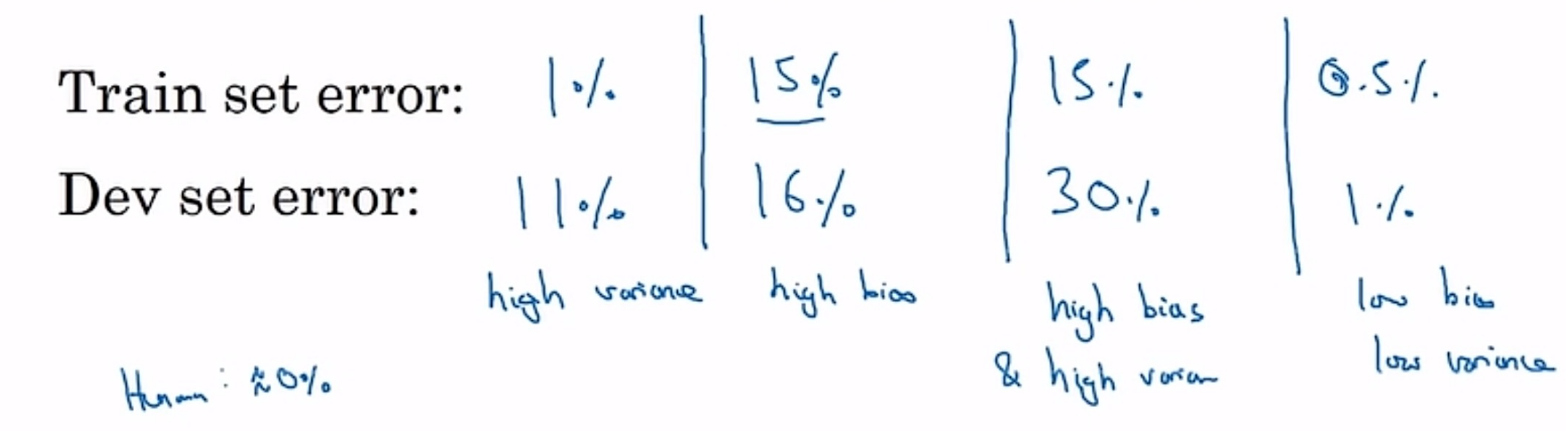

下面这这个图的紫色线条就是高偏差同时高方差的。几乎是个线性分类算法，所以欠拟合（高偏差）；却又在不该拟合的地方过拟合（高方差）
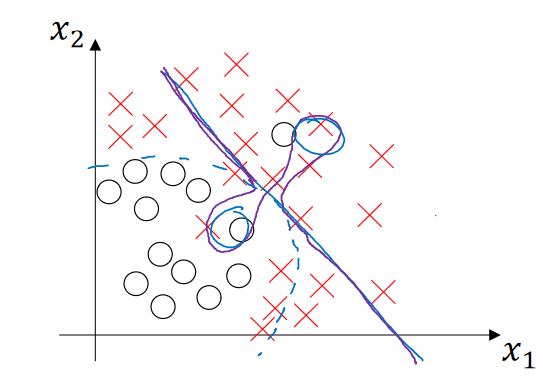

- 下图展示一个流程
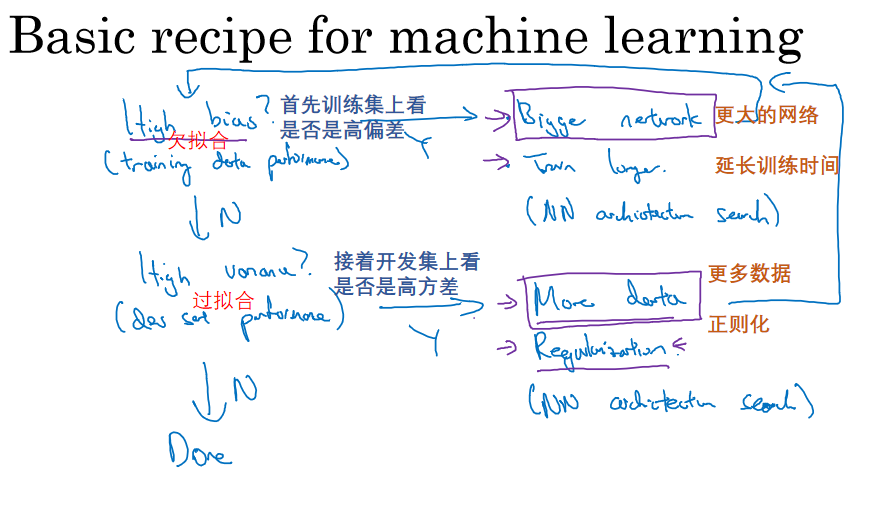

## 正则化
- L2正则化是最常见的方法
- 使用L1正则化，w最后会变得很稀疏。也就是w矢量中有很多0--但是在压缩模型上作用不大
- 正则化参数λ，通常使用开发集来配置       

矩阵范数
- 常用的：Frobenius 范数（F-范数）。即矩阵中每项数的平方和的开方值。
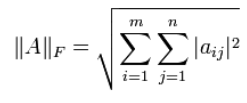 

反向传播时：L2正则化
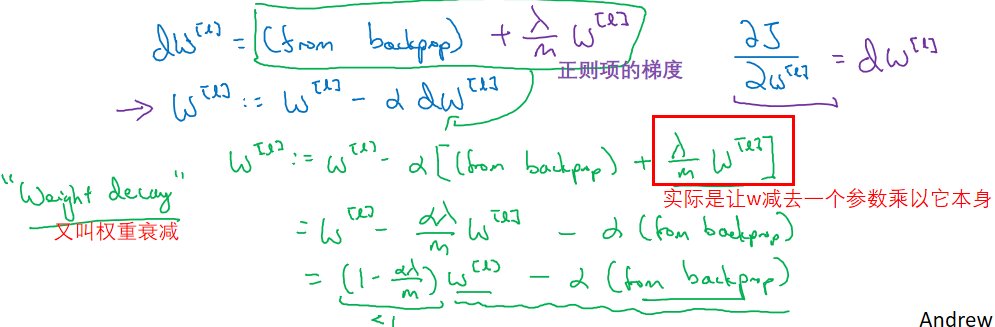

## 为什么正则化可以减少过拟合？
$$
J(\theta) =损失项+正则项  = \frac{1}{m} \sum_{i=1}^{m} \left( h_{\theta}(x^{(i)}) - y^{(i)} \right)^2 + \lambda \sum_{j=1}^{n} \theta_j^2
$$
$$
J(\mathbf{w}^{[l]}, \mathbf{b}^{[l]}) = \frac{1}{m} \sum_{i=1}^m L\left( \hat{y}^{(i)}, y^{(i)} \right) + \frac{\lambda}{2m} \sum_{l=1}^L \| \mathbf{w}^{[l]} \|_F^2
$$



- 如果 𝜆很大，那么正则化项的影响就会变得显著。
- 随着 𝜆的增大，正则化项对损失函数的贡献变得越来越大。为了最小化整个损失函数，优化算法（如梯度下降）会更加强烈地减小权重 𝜃的值，以减小正则化项 


一个直观的解释：          
假设使用tanh激活函数，靠近0附近的函数导数值接近于线性，无法起到很好的非线性激活作用。
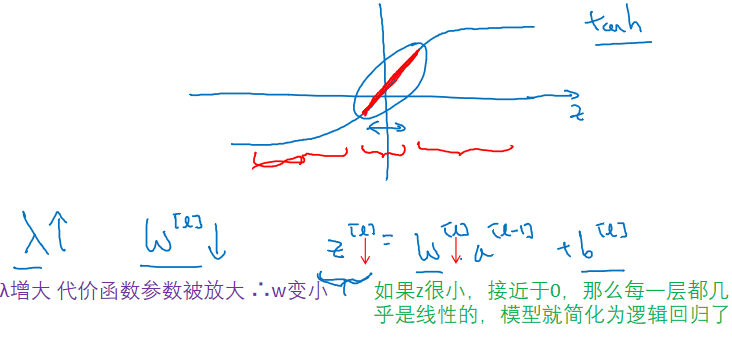

（上图展现的时λ很大的情况）      
### 总结   
<font color='#DA0D6'> 权重值过大会导致模型的复杂度增加，使其在训练集上能够表现良好，但在其他数据集上的泛化能力下降，从而出现过拟合现象。    
    为了避免过拟合，通常需要通过正则化方法（如权重衰减）来限制权重的大小 

## Dropout
作用：正则化技术 防止过拟合。但如果模型没有过拟合，那就不用dropout
- 为drop网络中某个节点置一个概率值，这使得每一次迭代都会在一个更小的神经网络中计算
- 不同层可以有不同的留存率 ，比如参数较多的层可以设定较小的留存率，缺点就是在交叉验证搜索时会有更多的参数

In [ ]:
'''
    inverted dropout（反向随机失活）正则化 Code
    这段代码仅在训练过程中使用。在测试或预测时，所有神经元都会被保留，并且不会对激活值进行缩放。
    - d3 是一个布尔矩阵，用于决定哪些神经元被保留（值为 True）哪些被丢弃（值为 False）。'''
d3=np.random.randn(a3.shape[0],a3.shpae[1])<keep_prob  # keep_prob=0.8 表示保留神经元的概率是 80%
a3=np.muitiply(a3,d3)
a3/=keep_prob

- $z^{[4]}=w^{[4]}*a^{[3]}+b^{[4]}$,为了确保z4的期望值不变，结果需要除以keep_prob，对保留的神经元激活值进行缩放

## 其他方法
数据增强       
- 翻转 随机裁剪图片 变形等      

早停法（Early Stopping）
1. 将原始的训练数据集划分成训练集和验证集
2. 只在训练集上进行训练，并每个一个周期计算模型在验证集上的误差，例如，每15次epoch（mini batch训练中的一个周期）
3. <font color='#C03B6'> 当模型在验证集上的误差比上一次训练结果差的时候停止训练</font> 
4. 使用上一次迭代结果中的参数作为模型的最终参数
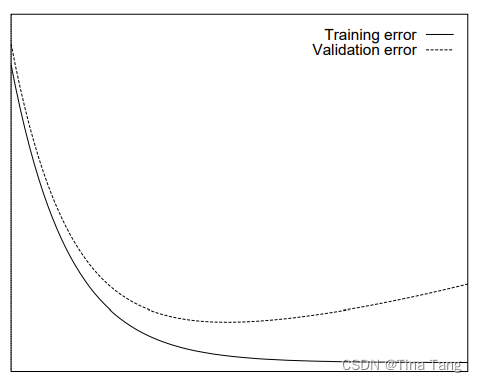

# 归一化输入
归一化：将数据转换为均值为 0，方差为 1 ，保证所有数据的特征尺度相近   
分为两步，**第一步是零均值化，第二步是归一化方差**
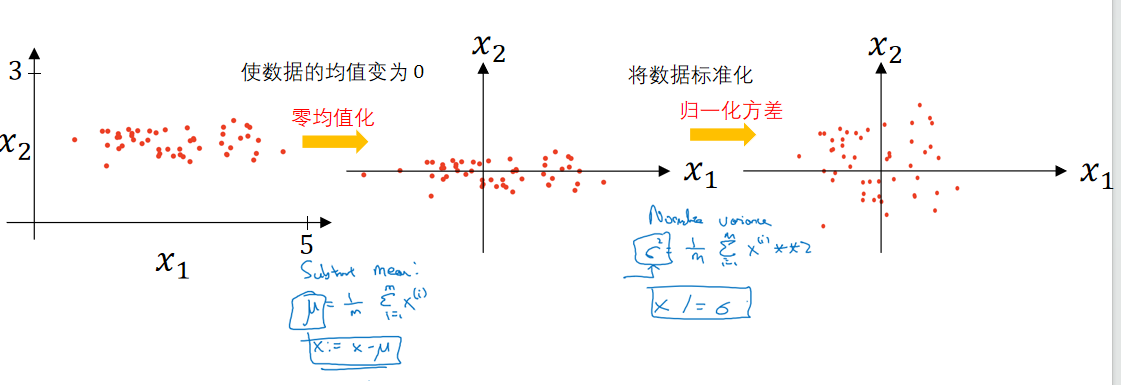
1. 零均值化

   $$ \mu = \frac{1}{m} \sum_{i=1}^{m} x^{(i)} $$


   $$ x := x - \mu $$


2. 归一化方差

$$
\sigma^2 = \frac{1}{m} \sum_{i=1}^{m} (x^{(i)} )^2 $$
$$x /=\sigma$$


注意：  
- 测试集和训练集的归一化方法应该一致，也就是$\sigma,\mu$值要一样


<font color='#007B6'>为什么要归一化？   [一个详细的参考链接](https://paddlepedia.readthedocs.io/en/latest/tutorials/deep_learning/normalization/basic_normalization.html)

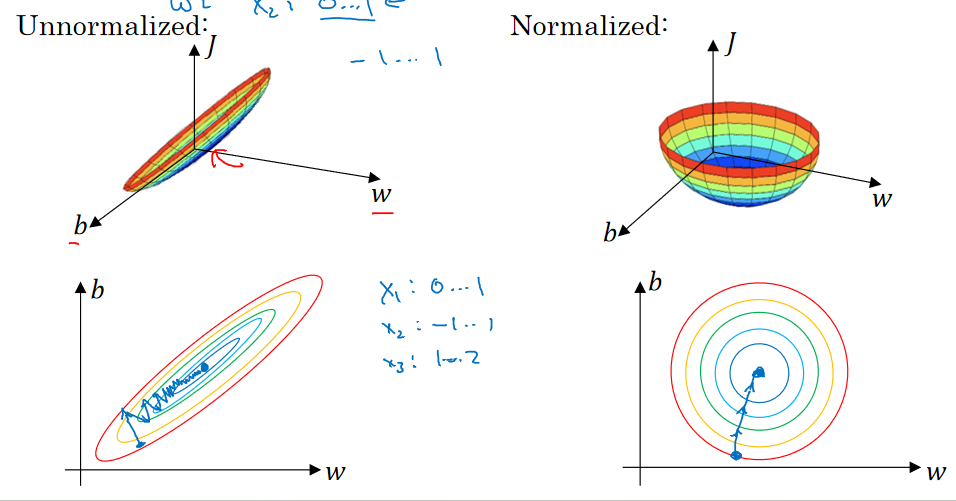

- 寻求最优解的过程就是梯度更新的过程，其更新方向与登高线垂直。由于x1和 x2的量级相差过大，损失函数的等高线呈现为一个瘦窄的椭圆。因此如图1（左）所示，瘦窄的椭圆形会使得梯度下降过程呈之字形呈现，导致梯度下降速度缓慢。         


- 归一化后的图像可以看到非常工整，不论从哪个点开始，都可以通过梯度下降法很快找到最小值，帮助学习算法运行得更快。